<a href="https://colab.research.google.com/github/obaidali12/house-price-prediction/blob/main/house_price_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  STEP 1: DATASET GENERATION

✅ Dataset created: 500 rows × 9 columns
 sqft_living  bedrooms  bathrooms  floors  yr_built  condition  garage  location_score  price
        1460         4        4.5       3      2019          4       1             5.9 522813
        5990         5        2.9       1      1953          2       0             6.2 753176
        5826         4        4.2       2      1992          3       1             6.5 858311
        5791         6        1.8       2      1987          2       1             5.5 805511
        4372         5        3.7       1      2008          1       1             6.8 646991
        3692         4        2.9       3      2001          2       0             9.3 683392
        6334         6        3.5       1      2005          1       0             4.9 792351
        6865         3        1.2       1      2003          1       1             7.8 893946

📊 Price stats:
count        $500
mean     $648,046
std      $175,188
min      $225,

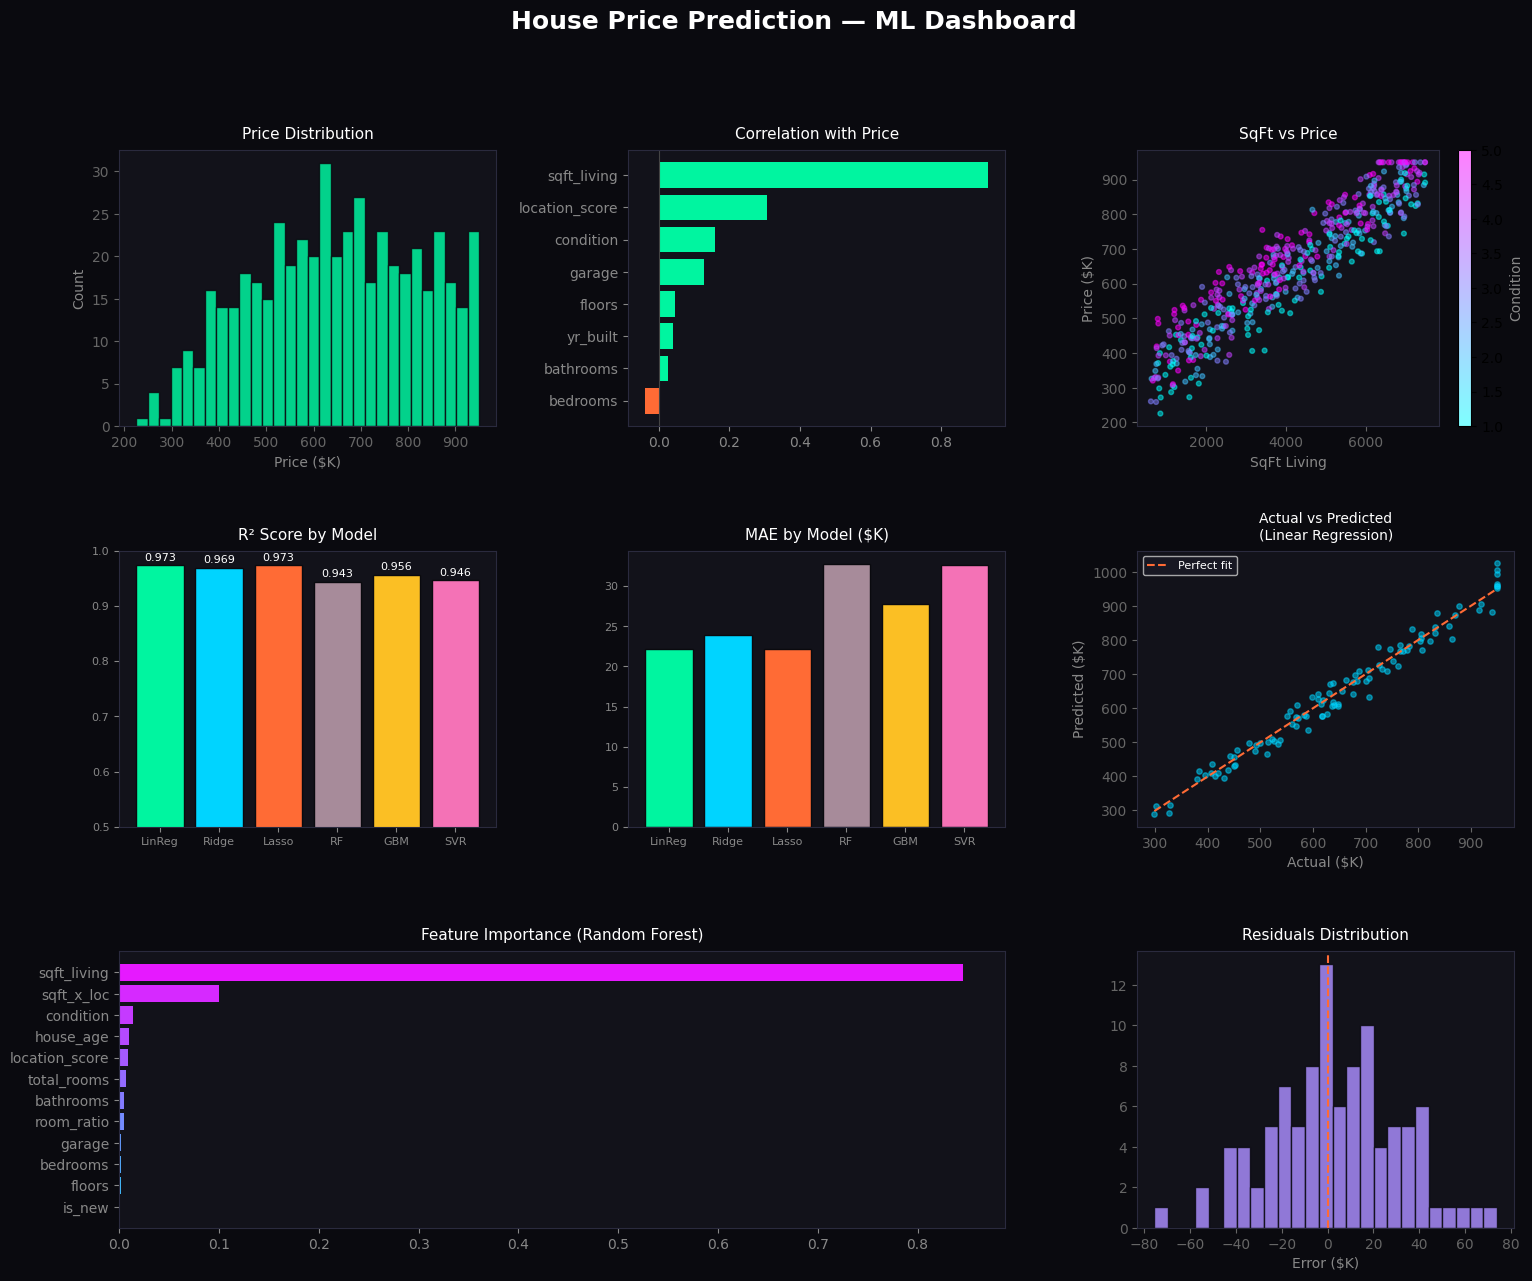

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# ─────────────────────────────
# STEP 1: GENERATE SYNTHETIC DATASET
# ─────────────────────────────
print("=" * 60)
print("  STEP 1: DATASET GENERATION")
print("=" * 60)

np.random.seed(42)
n = 500

sqft       = np.random.randint(600, 7500, n)
bedrooms   = np.random.randint(1, 7, n)
bathrooms  = np.round(np.random.uniform(1, 4.5, n), 1)
floors     = np.random.randint(1, 4, n)
yr_built   = np.random.randint(1940, 2023, n)
condition  = np.random.randint(1, 6, n)
garage     = np.random.randint(0, 2, n)
loc_score  = np.round(np.random.uniform(2, 10, n), 1)

# Price formula with realistic noise
price = (
    50_000
    + sqft       * 85
    + bedrooms   * 8_000
    + bathrooms  * 14_000
    + floors     * 8_000
    - (2024 - yr_built) * 600
    + condition  * 22_000
    + garage     * 28_000
    + loc_score  * 18_000
    + np.random.normal(0, 25_000, n)   # realistic noise
)
price = np.clip(price, 80_000, 950_000).astype(int)

df = pd.DataFrame({
    'sqft_living'   : sqft,
    'bedrooms'      : bedrooms,
    'bathrooms'     : bathrooms,
    'floors'        : floors,
    'yr_built'      : yr_built,
    'condition'     : condition,
    'garage'        : garage,
    'location_score': loc_score,
    'price'         : price,
})

print(f"\n✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(8).to_string(index=False))
print(f"\n📊 Price stats:")
print(df['price'].describe().apply(lambda x: f"${x:,.0f}" if x > 100 else f"{x:.2f}"))


# ─────────────────────────────
# STEP 2: EDA — Exploratory Data Analysis
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

print("\n📋 Data types:")
print(df.dtypes)
print(f"\n🔍 Null values: {df.isnull().sum().sum()} (none!)")

# Correlation with price
corr = df.corr()['price'].drop('price').sort_values(ascending=False)
print("\n📈 Feature correlations with price:")
for feat, val in corr.items():
    bar = "█" * int(abs(val) * 30)
    print(f"  {feat:<18} {val:+.3f}  {bar}")


# ─────────────────────────────
# STEP 3: FEATURE ENGINEERING
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 3: FEATURE ENGINEERING")
print("=" * 60)

def engineer_features(df):
    df = df.copy()
    df['house_age']    = 2024 - df['yr_built']                      # age is more intuitive
    df['room_ratio']   = df['bathrooms'] / df['bedrooms']           # bath-to-bed quality
    df['sqft_x_loc']   = df['sqft_living'] * df['location_score']   # interaction term
    df['is_new']       = (df['yr_built'] >= 2000).astype(int)       # binary flag
    df['total_rooms']  = df['bedrooms'] + df['bathrooms']
    df.drop(columns=['yr_built'], inplace=True)                     # replaced by house_age
    return df

df_eng = engineer_features(df)
new_feats = ['house_age', 'room_ratio', 'sqft_x_loc', 'is_new', 'total_rooms']
print(f"\n✅ New features added: {new_feats}")
print(f"   Total features now: {df_eng.shape[1]-1}")

# Features & target
FEATURES = [c for c in df_eng.columns if c != 'price']
X = df_eng[FEATURES]
y = df_eng['price']

print(f"\n🎯 Target (price): min=${y.min():,}  max=${y.max():,}  mean=${y.mean():,.0f}")
print(f"📦 Feature matrix: {X.shape}")


# ─────────────────────────────
# STEP 4: TRAIN / TEST SPLIT
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 4: TRAIN / TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Train set : {X_train.shape[0]} samples")
print(f"   Test  set : {X_test.shape[0]} samples")
print(f"   Split ratio: 80% / 20%")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✅ Features scaled with StandardScaler")


# ─────────────────────────────
# STEP 5: TRAIN MULTIPLE MODELS
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 5: TRAINING MODELS")
print("=" * 60)

models = {
    "Linear Regression"   : LinearRegression(),
    "Ridge Regression"    : Ridge(alpha=10),
    "Lasso Regression"    : Lasso(alpha=100),
    "Random Forest"       : RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    "SVR"                 : SVR(kernel='rbf', C=100_000, epsilon=5000),
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n  🔧 Training {name}...", end=' ')
    # Use scaled data for linear/svr, raw for tree-based
    use_scaled = name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "SVR"]
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values
    Xcv = X_train_sc if use_scaled else X_train.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, Xcv, y_train, cv=kf, scoring='r2').mean()

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv, 'model': model,
                     'y_pred': y_pred, 'scaled': use_scaled}
    print(f"✅  R²={r2:.4f}  MAE=${mae:,.0f}  CV={cv:.4f}")


# ─────────────────────────────
# STEP 6: EVALUATE & COMPARE
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 6: MODEL COMPARISON")
print("=" * 60)

summary = pd.DataFrame({
    name: {
        'R² Score' : f"{v['R2']:.4f}",
        'CV R²'    : f"{v['CV_R2']:.4f}",
        'MAE ($)'  : f"{v['MAE']:,.0f}",
        'RMSE ($)' : f"{v['RMSE']:,.0f}",
    }
    for name, v in results.items()
}).T

print("\n" + summary.to_string())

best_name = max(results, key=lambda k: results[k]['R2'])
print(f"\n🏆 Best model: {best_name}  (R²={results[best_name]['R2']:.4f})")


# ─────────────────────────────
# STEP 7: FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 7: FEATURE IMPORTANCE")
print("=" * 60)

rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\n📊 Random Forest Feature Importances:")
for feat, imp in importances.items():
    bar = "█" * int(imp * 60)
    print(f"  {feat:<18} {imp:.4f}  {bar}")


# ─────────────────────────────
# STEP 8: VISUALIZATIONS
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 8: GENERATING CHARTS")
print("=" * 60)

fig = plt.figure(figsize=(18, 14), facecolor='#0a0a0f')
fig.suptitle('House Price Prediction — ML Dashboard', fontsize=18,
             color='white', fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

COLORS = ['#00f5a0', '#00d4ff', '#ff6b35', '#a78b9a', '#fbbf24', '#f472b6']

# 1. Price Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#12121a')
ax1.hist(y / 1000, bins=30, color='#00f5a0', edgecolor='#0a0a0f', alpha=0.85)
ax1.set_title('Price Distribution', color='white', fontsize=11, pad=8)
ax1.set_xlabel('Price ($K)', color='#888')
ax1.set_ylabel('Count', color='#888')
ax1.tick_params(colors='#666')
for sp in ax1.spines.values(): sp.set_color('#2a2a3e')

# 2. Correlation heatmap (bar style)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#12121a')
corr_vals = df.corr()['price'].drop('price').sort_values()
colors_bar = ['#ff6b35' if v < 0 else '#00f5a0' for v in corr_vals]
ax2.barh(corr_vals.index, corr_vals.values, color=colors_bar)
ax2.set_title('Correlation with Price', color='white', fontsize=11, pad=8)
ax2.tick_params(colors='#888')
ax2.axvline(0, color='#444', linewidth=0.8)
for sp in ax2.spines.values(): sp.set_color('#2a2a3e')

# 3. SqFt vs Price scatter
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#12121a')
sc = ax3.scatter(df['sqft_living'], df['price']/1000, c=df['condition'],
                 cmap='cool', alpha=0.5, s=12)
ax3.set_title('SqFt vs Price', color='white', fontsize=11, pad=8)
ax3.set_xlabel('SqFt Living', color='#888')
ax3.set_ylabel('Price ($K)', color='#888')
ax3.tick_params(colors='#666')
for sp in ax3.spines.values(): sp.set_color('#2a2a3e')
plt.colorbar(sc, ax=ax3, label='Condition').ax.yaxis.label.set_color('#888')

# 4. Model R² Comparison
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#12121a')
names  = list(results.keys())
r2s    = [results[n]['R2'] for n in names]
short  = ['LinReg','Ridge','Lasso','RF','GBM','SVR']
bars   = ax4.bar(short, r2s, color=COLORS[:len(names)], edgecolor='#0a0a0f')
ax4.set_title('R² Score by Model', color='white', fontsize=11, pad=8)
ax4.set_ylim(0.5, 1.0)
ax4.tick_params(colors='#888', labelsize=8)
for sp in ax4.spines.values(): sp.set_color('#2a2a3e')
for bar, val in zip(bars, r2s):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=8)

# 5. MAE Comparison
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('#12121a')
maes = [results[n]['MAE']/1000 for n in names]
ax5.bar(short, maes, color=COLORS[:len(names)], edgecolor='#0a0a0f')
ax5.set_title('MAE by Model ($K)', color='white', fontsize=11, pad=8)
ax5.tick_params(colors='#888', labelsize=8)
for sp in ax5.spines.values(): sp.set_color('#2a2a3e')

# 6. Best model: Actual vs Predicted
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#12121a')
y_pred_best = results[best_name]['y_pred']
ax6.scatter(y_test/1000, y_pred_best/1000, alpha=0.5, color='#00d4ff', s=15)
mn, mx = y_test.min()/1000, y_test.max()/1000
ax6.plot([mn,mx],[mn,mx], '--', color='#ff6b35', linewidth=1.5, label='Perfect fit')
ax6.set_title(f'Actual vs Predicted\n({best_name})', color='white', fontsize=10, pad=8)
ax6.set_xlabel('Actual ($K)', color='#888')
ax6.set_ylabel('Predicted ($K)', color='#888')
ax6.tick_params(colors='#666')
ax6.legend(fontsize=8, facecolor='#1a1a26', labelcolor='white')
for sp in ax6.spines.values(): sp.set_color('#2a2a3e')

# 7. Feature Importance
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.set_facecolor('#12121a')
imp_sorted = importances.sort_values()
colors_fi  = plt.cm.cool(np.linspace(0.2, 0.9, len(imp_sorted)))
ax7.barh(imp_sorted.index, imp_sorted.values, color=colors_fi)
ax7.set_title('Feature Importance (Random Forest)', color='white', fontsize=11, pad=8)
ax7.tick_params(colors='#888')
for sp in ax7.spines.values(): sp.set_color('#2a2a3e')

# 8. Residuals
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor('#12121a')
residuals = y_test.values - y_pred_best
ax8.hist(residuals/1000, bins=25, color='#a78bfa', edgecolor='#0a0a0f', alpha=0.85)
ax8.axvline(0, color='#ff6b35', linewidth=1.5, linestyle='--')
ax8.set_title('Residuals Distribution', color='white', fontsize=11, pad=8)
ax8.set_xlabel('Error ($K)', color='#888')
ax8.tick_params(colors='#666')
for sp in ax8.spines.values(): sp.set_color('#2a2a3e')

plt.savefig('/content/ml_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
print("✅ Dashboard chart saved.")


# ─────────────────────────────
# STEP 9: PREDICTION FUNCTION
# ─────────────────────────────
print("\n" + "=" * 60)
print("  STEP 9: MAKE A PREDICTION")
print("=" * 60)

def predict_price(sqft_living, bedrooms, bathrooms, floors,
                  yr_built, condition, garage, location_score,
                  model_name='Random Forest'):
    """
    Predict house price given features.

    Parameters:
        sqft_living    : int   - Square footage
        bedrooms       : int   - Number of bedrooms
        bathrooms      : float - Number of bathrooms
        floors         : int   - Number of floors
        yr_built       : int   - Year built
        condition      : int   - Condition score (1–5)
        garage         : int   - Has garage (0 or 1)
        location_score : float - Neighborhood score (1–10)
        model_name     : str   - Which model to use

    Returns:
        dict with predicted price and confidence interval
    """
    input_data = pd.DataFrame([{
        'sqft_living'   : sqft_living,
        'bedrooms'      : bedrooms,
        'bathrooms'     : bathrooms,
        'floors'        : floors,
        'yr_built'      : yr_built,
        'condition'     : condition,
        'garage'        : garage,
        'location_score': location_score,
        'price'         : 0  # placeholder, dropped in engineer_features
    }])

    input_eng = engineer_features(input_data).drop(columns=['price'])
    input_eng = input_eng[FEATURES]

    model_info = results[model_name]
    if model_info['scaled']:
        input_scaled = scaler.transform(input_eng)
        pred = model_info['model'].predict(input_scaled)[0]
    else:
        pred = model_info['model'].predict(input_eng)[0]

    rmse = model_info['RMSE']
    return {
        'model'          : model_name,
        'predicted_price': f"${pred:,.0f}",
        'lower_bound'    : f"${max(0, pred - 1.96*rmse):,.0f}",
        'upper_bound'    : f"${pred + 1.96*rmse:,.0f}",
        'r2_score'       : f"{model_info['R2']:.4f}",
    }


# Example prediction
sample = predict_price(
    sqft_living=2200, bedrooms=3, bathrooms=2.5,
    floors=2, yr_built=2005, condition=4,
    garage=1, location_score=7.5
)

print("\n🏠 Sample Prediction:")
print(f"   Input  : 2200sqft, 3bed/2.5bath, 2005 built, condition=4, garage, loc=7.5")
for k, v in sample.items():
    print(f"   {k:<18}: {v}")

# Try all models
print("\n📊 All model predictions for same house:")
for mname in results:
    p = predict_price(2200,3,2.5,2,2005,4,1,7.5, model_name=mname)
    print(f"   {mname:<22}: {p['predicted_price']}")


print("\n" + "=" * 60)
print("  ✅ PIPELINE COMPLETE!")
print("  Files: house_price_prediction.py + ml_dashboard.png")
print("=" * 60)
